# 13 : 서울시 생활인구

노션 강의자료(13-1~3)가 아직 비어 있어, 실습 저장소
`lecture06_Living_Population`의 흐름을 따라 미리 구현했다.
자료가 공개되면 대조해 보완한다.

## 생활인구란

특정 시점에 그 지역에 **실제로 있는 사람 수**다. 주민등록 인구와 다르다.
통신·교통 데이터로 추정하며, 낮에는 도심이 늘고 밤에는 주거지가 는다.
도시가 어떻게 쓰이는지 보려면 등록인구보다 이쪽이 맞다.

## 데이터

| 파일 | 내용 |
| --- | --- |
| `data/raw/SPOP_2025_ADM.csv` | 원본 853MB · 3,731,760행 · 2025년 전체 |
| `data/processed/living_pop_daily.csv` | 일자 x 행정동 하루 평균 |
| `data/processed/living_pop_hourly.csv` | 시간대 x 행정동 연평균 |
| `data/processed/living_pop_age_gender.csv` | 행정동 x 성·연령 연평균 |
| `data/processed/seoul_dong_simplified.geojson` | 행정동 경계 426개 |

원본은 통째로 올리면 8GB 가까이 먹는다. `scripts/prepare_living_population.py`가
청크로 읽으며 집계만 누적해 위 파일들을 만든다 (약 11초).

API로도 받을 수 있지만 **최근 2개월치만** 제공해 시계열 분석이 안 된다.
그래서 서울 열린데이터광장에서 내려받은 연간 파일을 쓴다.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import plotly.express as px
import folium
from pathlib import Path

P = Path("data/processed")
FIG = Path("outputs/figures"); FIG.mkdir(parents=True, exist_ok=True)
HTML = Path("outputs/html"); HTML.mkdir(parents=True, exist_ok=True)

CODE = {"H_DNG_CD": "string"}
daily = pd.read_csv(P / "living_pop_daily.csv", dtype=CODE)
hourly = pd.read_csv(P / "living_pop_hourly.csv", dtype=CODE)
ageg = pd.read_csv(P / "living_pop_age_gender.csv", dtype=CODE)

print("일별", daily.shape, "| 시간대별", hourly.shape, "| 성연령", ageg.shape)
daily.head(3)

일별 (155490, 6) | 시간대별 (10224, 6) | 성연령 (426, 20)


,YMD,H_DNG_CD,SPOP,SIDO_NM,SGG_NM,ADMI_NM
0,20250101,11110515,16152.72,서울특별시,종로구,청운효자동
1,20250101,11110530,16953.63,서울특별시,종로구,사직동
2,20250101,11110540,4040.67,서울특별시,종로구,삼청동


## 1. 행정동 코드 체계가 기관마다 다르다

이 실습에서 제일 먼저 막히는 지점이다.

| 기관 | 종로구 사직동 | 구조 |
| --- | --- | --- |
| 통계청(SGIS) 경계 | `11010530` | 시도2 + 시군구3 + 동3 |
| 서울 생활인구 | `11110530` | 행정동코드 앞 8자리 |

426개 중 **32개만 우연히 일치**한다. 코드로 붙이면 394개가 날아간다.
이름으로 이어야 하는데 표기도 다르다 — `종로1·2·3·4가동`(가운뎃점) vs
`종로1.2.3.4가동`(마침표).

`scripts/build_dong_crosswalk.py`가 구분자를 지우고 (시군구명, 동명)으로
맞춰 426개 전부 이었다. 경계 파일에 생활인구 코드를 미리 붙여 뒀으므로
아래에서는 `H_DNG_CD` 하나로 조인된다.

In [2]:
geo = gpd.read_file(P / "seoul_dong_simplified.geojson")
print(geo.shape, geo.crs)
print(geo[["SGIS_CD", "DONG_NM", "SGG_NM", "H_DNG_CD"]].head(3).to_string(index=False))

# 조인이 실제로 되는지 먼저 확인한다. 행 수가 변하면 키가 잘못된 것이다.
dong_avg = daily.groupby("H_DNG_CD", as_index=False)["SPOP"].mean()
m = geo.merge(dong_avg, on="H_DNG_CD", how="left")
print(f"\n경계 {len(geo)} → 조인 {len(m)}  미매칭 {m['SPOP'].isna().sum()}")

(426, 5) EPSG:4326
 SGIS_CD DONG_NM SGG_NM H_DNG_CD
11010530     사직동    종로구 11110530
11010540     삼청동    종로구 11110540
11010550     부암동    종로구 11110550

경계 426 → 조인 426  미매칭 0


## 2. 시간대별 — 도시는 하루 동안 움직인다

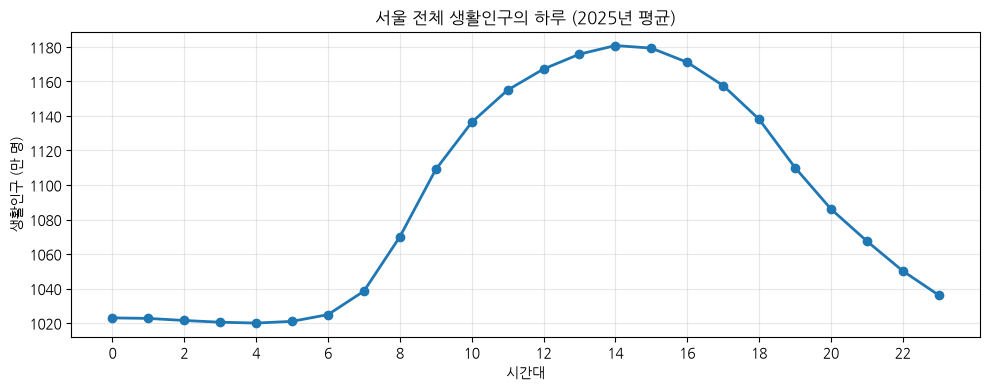

최다 14시  1,180.8만 명
최소  4시  1,020.0만 명
차이 160.8만 명 (15.8%)


In [3]:
seoul_hourly = hourly.groupby("TT", as_index=False)["SPOP"].sum()
seoul_hourly["SPOP_만명"] = (seoul_hourly["SPOP"] / 10000).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(seoul_hourly["TT"], seoul_hourly["SPOP_만명"], marker="o", linewidth=2)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("시간대")
ax.set_ylabel("생활인구 (만 명)")
ax.set_title("서울 전체 생활인구의 하루 (2025년 평균)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "13_1.png", dpi=120)
plt.show()

peak = seoul_hourly.loc[seoul_hourly["SPOP"].idxmax()]
low = seoul_hourly.loc[seoul_hourly["SPOP"].idxmin()]
print(f"최다 {int(peak['TT']):2d}시  {peak['SPOP_만명']:,.1f}만 명")
print(f"최소 {int(low['TT']):2d}시  {low['SPOP_만명']:,.1f}만 명")
print(f"차이 {peak['SPOP_만명'] - low['SPOP_만명']:,.1f}만 명 "
      f"({(peak['SPOP']/low['SPOP']-1)*100:.1f}%)")

## 3. 주간인구 대 야간인구

같은 동이라도 낮과 밤의 인구가 크게 다르다. 그 비율이 그 동네의 성격을 말해 준다.

- 비율이 높으면 **일하러 오는 곳** (업무지구)
- 비율이 낮으면 **자러 가는 곳** (주거지)

In [4]:
# 낮 11-15시, 밤 2-5시를 대표 구간으로 잡는다
day = hourly[hourly["TT"].between(11, 15)].groupby("H_DNG_CD")["SPOP"].mean()
night = hourly[hourly["TT"].between(2, 5)].groupby("H_DNG_CD")["SPOP"].mean()

ratio = pd.DataFrame({"주간": day, "야간": night})
ratio["주야간비"] = (ratio["주간"] / ratio["야간"]).round(2)
ratio = ratio.reset_index().merge(
    hourly[["H_DNG_CD", "SGG_NM", "ADMI_NM"]].drop_duplicates(), on="H_DNG_CD")

print("주간인구가 야간의 몇 배인가 — 상위 10")
display(ratio.nlargest(10, "주야간비")[["SGG_NM", "ADMI_NM", "주간", "야간", "주야간비"]]
        .round(0).to_string(index=False))

print("\n하위 10 (전형적인 주거지)")
display(ratio.nsmallest(10, "주야간비")[["SGG_NM", "ADMI_NM", "주간", "야간", "주야간비"]]
        .round(0).to_string(index=False))

주간인구가 야간의 몇 배인가 — 상위 10


'SGG_NM     ADMI_NM       주간      야간  주야간비\n    중구          명동  89451.0  8249.0  11.0\n    중구         소공동  66983.0  6411.0  10.0\n    중구         회현동  62794.0  8071.0   8.0\n   종로구 종로1.2.3.4가동 130637.0 20183.0   6.0\n    중구        을지로동  30084.0  4926.0   6.0\n   강남구        삼성1동  78483.0 16058.0   5.0\n   종로구         사직동  53095.0 11926.0   4.0\n    중구          필동  26831.0  6129.0   4.0\n   종로구     종로5.6가동  31518.0  7426.0   4.0\n  영등포구         여의동 177670.0 43725.0   4.0'


하위 10 (전형적인 주거지)


'SGG_NM ADMI_NM      주간      야간  주야간비\n   노원구    하계2동 11517.0 17478.0   1.0\n   성동구     응봉동  9929.0 14597.0   1.0\n   성동구    행당2동 16903.0 24350.0   1.0\n   은평구    응암2동 18355.0 26249.0   1.0\n   관악구     청림동  6999.0 10068.0   1.0\n   관악구     성현동 19491.0 27475.0   1.0\n   관악구     서림동 16534.0 23202.0   1.0\n  서대문구    홍제2동  9145.0 12660.0   1.0\n  서대문구   북가좌1동 13228.0 18267.0   1.0\n   동작구    상도4동 21926.0 30472.0   1.0'

## 4. 지도로 보기

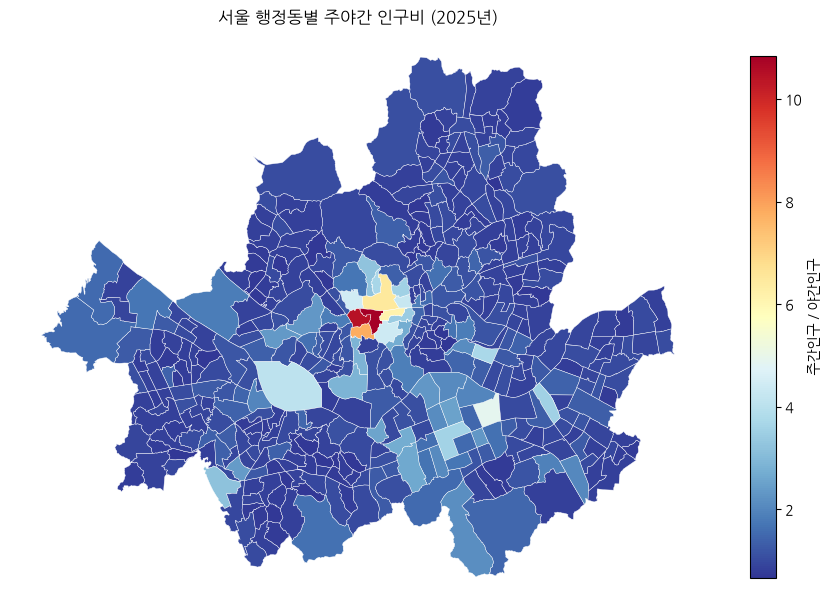

In [5]:
g = geo.merge(ratio[["H_DNG_CD", "주야간비", "주간", "야간"]], on="H_DNG_CD", how="left")

fig, ax = plt.subplots(figsize=(9, 9))
g.plot(column="주야간비", cmap="RdYlBu_r", legend=True, ax=ax,
       edgecolor="white", linewidth=0.3,
       legend_kwds={"label": "주간인구 / 야간인구", "shrink": 0.6})
ax.set_title("서울 행정동별 주야간 인구비 (2025년)")
ax.axis("off")
fig.tight_layout()
fig.savefig(FIG / "13_2.png", dpi=120)
plt.show()

In [6]:
import json

m = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=json.loads(g.to_json()),
    data=g, columns=["H_DNG_CD", "주야간비"],
    key_on="feature.properties.H_DNG_CD",
    fill_color="RdYlBu_r", fill_opacity=0.75, line_opacity=0.3,
    nan_fill_color="lightgrey",
    legend_name="주간인구 / 야간인구",
).add_to(m)

folium.GeoJson(
    json.loads(g.to_json()),
    style_function=lambda _: {"fillColor": "transparent", "color": "transparent"},
    tooltip=folium.GeoJsonTooltip(
        fields=["SGG_NM", "DONG_NM", "주야간비", "주간", "야간"],
        aliases=["자치구", "행정동", "주야간비", "주간인구", "야간인구"],
        localize=True),
).add_to(m)

m.save(HTML / "13_1.html")
m

/Users/taecinkim/Documents/Lab/smartcity/.venv/lib/python3.12/site-packages/folium/raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


## 5. 연중 변화

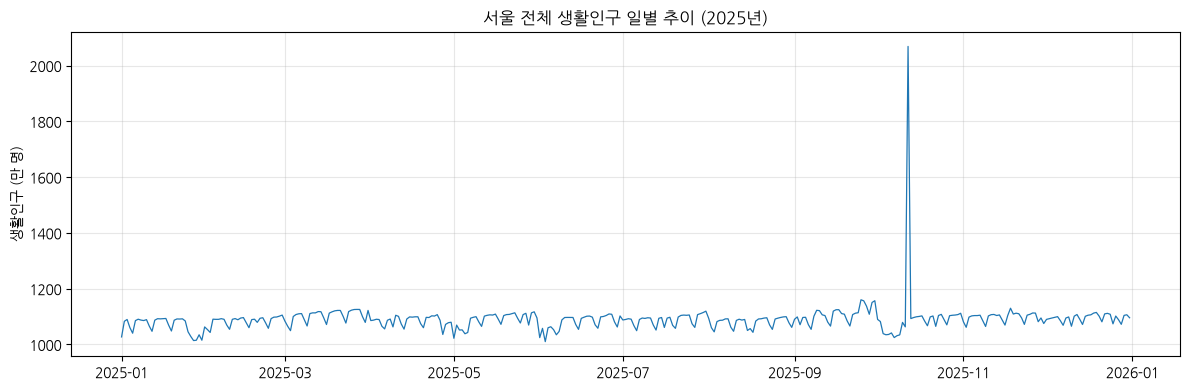

요일별 평균 (만 명):
  월  1,092.9
  화  1,096.0
  수  1,092.0
  목  1,097.0
  금  1,097.9
  토  1,077.2
  일  1,078.8


In [7]:
d = daily.copy()
d["date"] = pd.to_datetime(d["YMD"], format="%Y%m%d")
seoul_daily = d.groupby("date", as_index=False)["SPOP"].sum()
seoul_daily["요일"] = seoul_daily["date"].dt.dayofweek

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(seoul_daily["date"], seoul_daily["SPOP"] / 10000, linewidth=0.9)
ax.set_ylabel("생활인구 (만 명)")
ax.set_title("서울 전체 생활인구 일별 추이 (2025년)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "13_3.png", dpi=120)
plt.show()

names = ["월", "화", "수", "목", "금", "토", "일"]
byday = seoul_daily.groupby("요일")["SPOP"].mean() / 10000
print("요일별 평균 (만 명):")
for i, v in byday.items():
    print(f"  {names[i]}  {v:,.1f}")

## 6. 성·연령 구조

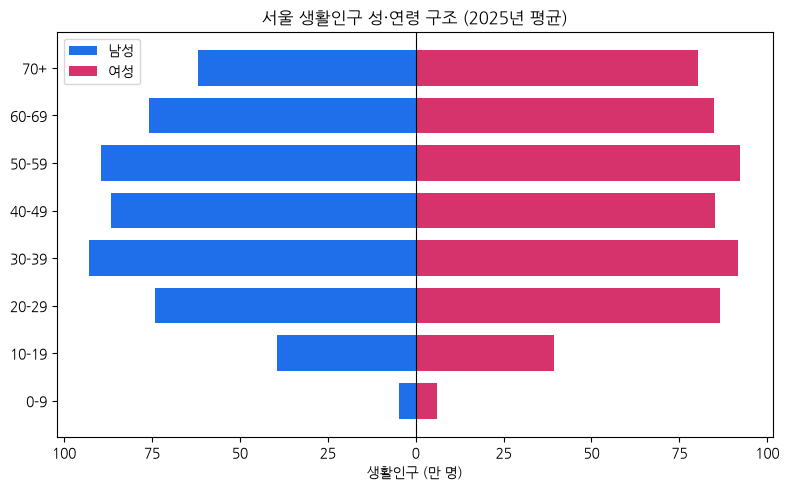

In [8]:
AGE = ["00", "10", "20", "30", "40", "50", "60", "70"]
LABEL = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70+"]

tot = ageg[[f"{g}{a}" for g in "MF" for a in AGE]].sum()
male = [tot[f"M{a}"] for a in AGE]
female = [tot[f"F{a}"] for a in AGE]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(AGE))
ax.barh(y, [-v / 10000 for v in male], height=0.75, label="남성", color="#1f6feb")
ax.barh(y, [v / 10000 for v in female], height=0.75, label="여성", color="#d6336c")
ax.set_yticks(y); ax.set_yticklabels(LABEL)
ax.set_xlabel("생활인구 (만 명)")
ax.set_title("서울 생활인구 성·연령 구조 (2025년 평균)")
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(lambda x, _: f"{abs(x):,.0f}")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "13_4.png", dpi=120)
plt.show()

## 7. 관악구는 어떤가

수업 저장소의 다른 작업이 관악캠퍼스 주변을 다루므로 함께 본다.

In [9]:
gwanak = ratio[ratio["SGG_NM"] == "관악구"].sort_values("주야간비", ascending=False)
print(f"관악구 행정동 {len(gwanak)}개\n")
display(gwanak[["ADMI_NM", "주간", "야간", "주야간비"]].round(0).to_string(index=False))

fig = px.bar(gwanak.sort_values("주야간비"), x="주야간비", y="ADMI_NM",
             orientation="h", color="주야간비", color_continuous_scale="RdYlBu_r",
             labels={"주야간비": "주간 / 야간", "ADMI_NM": ""})
fig.update_layout(title="관악구 행정동별 주야간 인구비",
                  template="plotly_white", height=520)
fig.write_html(HTML / "13_2.html", include_plotlyjs="cdn")
fig.show()

관악구 행정동 21개



'ADMI_NM      주간      야간  주야간비\n    대학동 43441.0 26678.0   2.0\n    조원동 28479.0 23152.0   1.0\n   낙성대동 24029.0 22907.0   1.0\n    남현동 22003.0 22394.0   1.0\n    청룡동 38266.0 40230.0   1.0\n    서원동 23200.0 26974.0   1.0\n    미성동 25575.0 29973.0   1.0\n    신림동 24437.0 28813.0   1.0\n    삼성동 22095.0 26378.0   1.0\n   보라매동 18780.0 22635.0   1.0\n    중앙동 13028.0 15920.0   1.0\n    인헌동 20647.0 25631.0   1.0\n    은천동 27143.0 34307.0   1.0\n    난곡동 19003.0 24319.0   1.0\n    신사동 16518.0 21571.0   1.0\n    행운동 24287.0 32033.0   1.0\n    신원동 14198.0 19362.0   1.0\n    난향동 10870.0 14936.0   1.0\n    서림동 16534.0 23202.0   1.0\n    성현동 19491.0 27475.0   1.0\n    청림동  6999.0 10068.0   1.0'

### 읽어낸 것

- 서울 전체 생활인구는 새벽 4시에 가장 적고 오후 2시에 가장 많다. 그 차이가 하루의 진폭이다.
- 주야간비가 높은 동은 업무·상업지구, 낮은 동은 주거지다. 같은 서울 안에서도 쓰임이 갈린다.
- 관악구는 대체로 주거지 성격이 강하다. 다만 동마다 편차가 있다.

주의: 생활인구는 통신 데이터 기반 **추정치**다. 등록인구와 다르며,
행정동 경계 근처에서는 귀속이 흔들릴 수 있다.